Dieser Code trainiert und evaluiert zwei Naive Bayes Modelle mit der Vektorisierung Bag of Words anhand dieses Datensatzes:

@inproceedings{tonneau-etal-2024-languages,

    title = "From Languages to Geographies: Towards Evaluating Cultural Bias in Hate Speech Datasets",

    author = {Tonneau, Manuel  and
      Liu, Diyi  and
      Fraiberger, Samuel  and
      Schroeder, Ralph  and
      Hale, Scott  and
      Röttger, Paul},
    editor = {Chung, Yi-Ling  and
      Talat, Zeerak  and
      Nozza, Debora  and
      Plaza-del-Arco, Flor Miriam  and
      Röttger, Paul  and
      Mostafazadeh Davani, Aida  and
      Calabrese, Agostina},
    
    booktitle = "Proceedings of the 8th Workshop on Online Abuse and Harms (WOAH 2024)",
    month = jun,
    year = "2024",
    address = "Mexico City, Mexico",
    publisher = "Association for Computational Linguistics",
    url = "https://aclanthology.org/2024.woah-1.23",
    pages = "283--311",
    abstract = "Perceptions of hate can vary greatly across cultural contexts.
    Hate speech (HS) datasets, however, have traditionally been developed by
    language. This hides potential cultural biases, as one language may be
    spoken in different countries home to different cultures. In this work, we
    evaluate cultural bias in HS datasets by leveraging two interrelated
    cultural proxies: language and geography. We conduct a systematic survey
    of HS datasets in eight languages and confirm past findings on their
    English-language bias, but also show that this bias has been steadily
    decreasing in the past few years. For three geographically-widespread
    languages{---}English, Arabic and Spanish{---}we then leverage
    geographical metadata from tweets to approximate geo-cultural contexts by
    pairing language and country information. We find that HS datasets for
    these languages exhibit a strong geo-cultural bias, largely
    overrepresenting a handful of countries (e.g., US and UK for English)
    relative to their prominence in both the broader social media population
    and the general population speaking these languages. Based on these
    findings, we formulate recommendations for the creation of future HS
    datasets.",}
Die Vektorisierung erfoglt über Bag of Words.



Imports

In [2]:
 import pandas as pd
 import matplotlib.pyplot  as plt
 import seaborn as sns
 import numpy as np
 import sklearn
 import sklearn.metrics as metrics


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Datensatz**

In [4]:
#Datensatz importieren

df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/de_hf_112024.csv",sep=",",engine="python",on_bad_lines="skip",encoding="utf-8")
df.head()


,text,labels,source,dataset,nb_annotators
0,gleich an die wand stellen und erschiessen..,1.0,Facebook,Bretschneider,2.0
1,nicht dass ich der Grundbotschaft dieses Post'...,0.0,Facebook,Bretschneider,2.0
2,"Das mit dem ""an die Wand stellen und erschiessen""",0.0,Facebook,Bretschneider,2.0
3,"Seit dem ""an die Wand stellen und erschiessen""...",0.0,Facebook,Bretschneider,2.0
4,Ja ja die Kriminelle Heimatpartei FPÖ von Kind...,0.0,Facebook,Bretschneider,2.0


In [5]:
# wie viel Hasskommentare gibt es im Datensatz?
df["labels"].value_counts()

,count
labels,
0.0,44246
1.0,6297


In [6]:
df.groupby("dataset")["labels"].value_counts()

dataset        labels
Bretschneider  0.0        5116
               1.0         562
RP-mod-crowd   0.0       27968
               1.0         863
gahd           0.0        6330
               1.0        4666
hasoc          0.0        4517
               1.0         152
refugees       0.0         315
               1.0          54
Name: count, dtype: int64

In [7]:
# welche Datasets sind es?
df["dataset"].value_counts()

,count
dataset,
RP-mod-crowd,28831
gahd,10996
Bretschneider,5678
hasoc,4669
refugees,369


In [8]:
# woher kommen die Kommentare?
df["source"].value_counts()

,count
source,
news_comments,28831
Synthetic,10996
Facebook,5678
Twitter + Facebook,4669
Twitter,369


In [9]:
df["labels"].isna().sum()
df[df["labels"].isna()]


,text,labels,source,dataset,nb_annotators
2519,Das macht Angst....,NaN,None,None,NaN


In [10]:
df=df.dropna(subset=["labels"])

In [11]:
df["labels"].isna().sum()

np.int64(0)

**Trainings -/ Test- /Validierungsdatensatz**

In [12]:
from sklearn.model_selection import train_test_split
X=df["text"]
y=df["labels"].astype(int)

In [13]:
#TRAIN /TEST
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
#TRAIN / VALIDATION
X_train, X_val, y_train, y_val = train_test_split( X_train, y_train, test_size=0.1, random_state=42)

# Naive Bayes mit Bag of Words

**Daten Vektorisierung**

In [ ]:
pip install nltk

In [14]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [15]:
from nltk.corpus import stopwords
german_stopwords=stopwords.words("german")

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

vekt=CountVectorizer(
    lowercase=True,
    stop_words=german_stopwords,
    ngram_range=(1,1)
    )

X_train_vex=vekt.fit_transform(X_train)
X_test_vex=vekt.transform(X_test)
X_val_vex=vekt.transform(X_val)

**Modell Training**

In [17]:
from sklearn.naive_bayes import MultinomialNB

model=MultinomialNB()
model.fit(X_train_vex,y_train)

MultinomialNB()

**Validierung**
dient zur Validierung während der Entwicklung

In [18]:
#validieren
y_val_pred=model.predict(X_val_vex)
y_val_proba=model.predict_proba(X_val_vex)[:,1] #[2 spaltrige matrix spalte 0 K hasskommentar/ spalte 1 hasskommentar]

#wahrscheinlichkeiten in datei schreiben
with open("naive_bayes_BoW.txt", "w") as fd:
  for text, labels, proba in zip(X_val,y_val, y_val_proba):
    fd.write(f"Text: {text}\n")
    fd.write(f"Label: {labels}\n")
    fd.write(f"Wahrscheinlichkeit Hasskommentar: {proba}\n")
    fd.write("\n"*4)
#beste Klassifikationsschwelle finden
schwelle = np.arange(0.0,1.01,0.01)
beste_schwelle = 0
beste_f1 = 0

for t in schwelle:
  y_val_pred_schwelle = np.where(y_val_proba > t, 1, 0)
  f1 = metrics.f1_score(y_val, y_val_pred_schwelle)
  if f1 > beste_f1:
    beste_f1 = f1
    beste_schwelle = t
    print("Beste Schwelle: ", beste_schwelle)
    print("Bester F1 Score: ", beste_f1)

print("Final beste Schwelle: ", beste_schwelle)
print("Bester F1 Score: ", beste_f1)

Beste Schwelle:  0.0
Bester F1 Score:  0.2185022026431718
Beste Schwelle:  0.01
Bester F1 Score:  0.41254523522316044
Beste Schwelle:  0.02
Bester F1 Score:  0.4441360166551006
Beste Schwelle:  0.03
Bester F1 Score:  0.4595808383233533
Beste Schwelle:  0.04
Bester F1 Score:  0.4667201283079391
Beste Schwelle:  0.05
Bester F1 Score:  0.4719665271966527
Beste Schwelle:  0.06
Bester F1 Score:  0.4767747589833479
Beste Schwelle:  0.11
Bester F1 Score:  0.4792719919110212
Beste Schwelle:  0.13
Bester F1 Score:  0.4807692307692308
Final beste Schwelle:  0.13
Bester F1 Score:  0.4807692307692308


In [19]:
 print("BEster Klassifikationsschwellenwert: ", beste_schwelle)

BEster Klassifikationsschwellenwert:  0.13


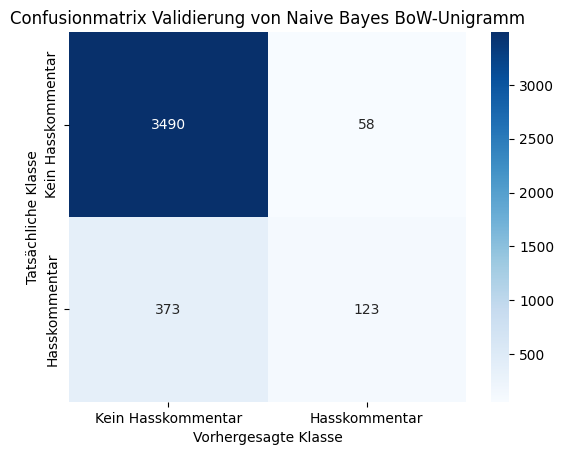

In [22]:
# Confusion Matrix

cm = metrics.confusion_matrix(y_val, y_val_pred)
sns.heatmap(
    cm,
    annot=True, #zeigt werte an, annotation
    fmt="d", # integer gibt ganze zahl an, sonst mit nachkommastellen
    cmap="Blues",# farbpalette, helle farbe = kleiner wert / dunkle farbe = hoher wert
    xticklabels=["Kein Hasskommentar","Hasskommentar"], #beschriftung der x achse
    yticklabels=["Kein Hasskommentar","Hasskommentar"] #beschriftung y achse
)
plt.title("Confusionmatrix Validierung von Naive Bayes BoW-Unigramm")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [23]:
# accuracy
vaccuracy = metrics.accuracy_score(y_val, y_val_pred)
# precision
vprecision = metrics.precision_score(y_val, y_val_pred)
# recall
vrecall = metrics.recall_score(y_val, y_val_pred)
# f1-score
vf1=metrics.f1_score(y_val, y_val_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_val, y_val_pred).ravel()
vspecificity = tn/(tn+fp)
# macro recall
vmacro_recall=metrics.recall_score(y_val, y_val_pred, average='macro')
# macro f1-score
vmacro_f1=metrics.f1_score(y_val, y_val_pred, average='macro')

In [24]:
print("Accuracy: ", vaccuracy)
print("Precision: ", vprecision)
print("Recall: ", vrecall)
print("Specificity: ", vspecificity)
print("F1-Score: ", vf1)
print("Macro Recall: ", vmacro_recall)
print("Macro F1-Score: ", vmacro_f1)

Accuracy:  0.8934223541048467
Precision:  0.6795580110497238
Recall:  0.24798387096774194
Specificity:  0.9836527621195039
F1-Score:  0.36336779911373707
Macro Recall:  0.615818316543623
Macro F1-Score:  0.6526055025794026


**Evaluation mit Standard Schwellenwert**

In [25]:
y_test_pred=model.predict(X_test_vex)
y_test_proba=model.predict_proba(X_test_vex)[:,1] #[2 spaltrige matrix spalte 0 K hasskommentar/ spalte 1 hasskommentar]

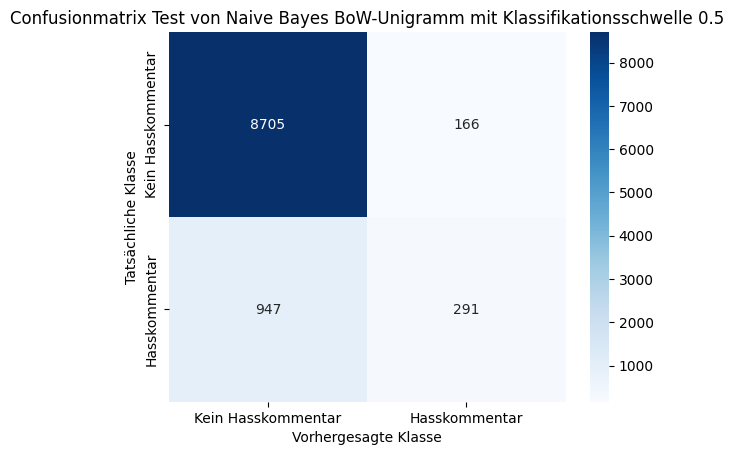

In [26]:
#Confusion MAtrix
# Confusion Matrix

cm = metrics.confusion_matrix(y_test, y_test_pred)
sns.heatmap(
    cm,
    annot=True, #zeigt werte an, annotation
    fmt="d", # integer gibt ganze zahl an, sonst mit nachkommastellen
    cmap="Blues",# farbpalette, helle farbe = kleiner wert / dunkle farbe = hoher wert
    xticklabels=["Kein Hasskommentar","Hasskommentar"], #beschriftung der x achse
    yticklabels=["Kein Hasskommentar","Hasskommentar"] #beschriftung y achse
)
plt.title("Confusionmatrix Test von Naive Bayes BoW-Unigramm mit Klassifikationsschwelle 0.5")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [27]:
# accuracy
accuracy = metrics.accuracy_score(y_test, y_test_pred)
# precision
precision = metrics.precision_score(y_test,  y_test_pred)
# recall
recall = metrics.recall_score(y_test,  y_test_pred)
# f1-score
f1=metrics.f1_score(y_test,  y_test_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test,  y_test_pred).ravel()
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test,  y_test_pred, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_test_pred, average='macro')

In [28]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.8899000890295776
Precision:  0.6367614879649891
Recall:  0.23505654281098545
Specificity:  0.9812873407733063
F1-Score:  0.3433628318584071
Macro Recall:  0.6081719417921458
Macro F1-Score:  0.6416376865117226


**Evaluationen mit optimierten Schwellenwert**

In [29]:
y_test_proba=model.predict_proba(X_test_vex)[:,1] # mit schwellen wert
y_test_pred_opt=(y_test_proba>beste_schwelle).astype(int) # mit optimaler schwellen wert

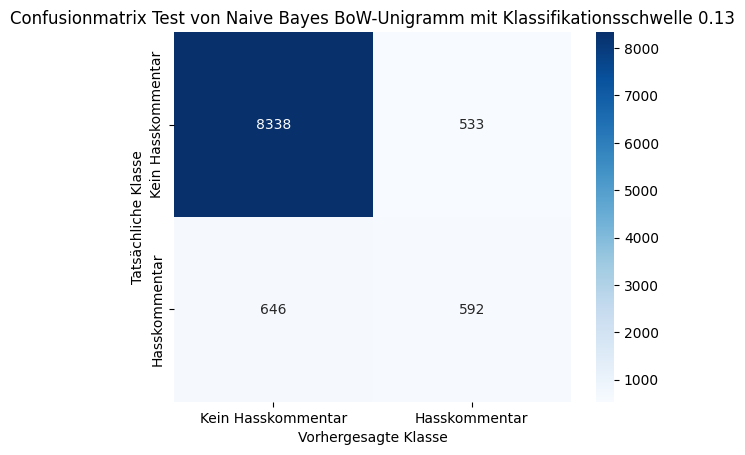

In [30]:
# Confusion Matrix

cm = metrics.confusion_matrix(y_test, y_test_pred_opt)
sns.heatmap(
    cm,
    annot=True, #zeigt werte an, annotation
    fmt="d", # integer gibt ganze zahl an, sonst mit nachkommastellen
    cmap="Blues",# farbpalette, helle farbe = kleiner wert / dunkle farbe = hoher wert
    xticklabels=["Kein Hasskommentar","Hasskommentar"], #beschriftung der x achse
    yticklabels=["Kein Hasskommentar","Hasskommentar"] #beschriftung y achse
)
plt.title("Confusionmatrix Test von Naive Bayes BoW-Unigramm mit Klassifikationsschwelle 0.13")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [31]:
# accuracy
accuracy = metrics.accuracy_score(y_test, y_test_pred_opt)
# precision
precision = metrics.precision_score(y_test,  y_test_pred_opt)
# recall
recall = metrics.recall_score(y_test,  y_test_pred_opt)
# f1-score
f1=metrics.f1_score(y_test,  y_test_pred_opt)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test,  y_test_pred_opt).ravel()
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test,  y_test_pred_opt, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_test_pred_opt, average='macro')

In [32]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.8833712533386091
Precision:  0.5262222222222223
Recall:  0.4781906300484653
Specificity:  0.9399165821215195
F1-Score:  0.5010579771476936
Macro Recall:  0.7090536060849923
Macro F1-Score:  0.717513026658417


In [ ]:
#Modell speichern
import joblib
joblib.dump(model,"/content/drive/MyDrive/Colab Notebooks/naive_bayes_BoW_model.plk")

['/content/drive/MyDrive/Colab Notebooks/naive_bayes_BoW_model.plk']

# Naive Bayes mit BoW-Bigram ohne Stoppwords



In [33]:
from sklearn.feature_extraction.text import CountVectorizer
vekt=CountVectorizer(
    lowercase=True,
    ngram_range=(1,2)
    )

X_train_vex=vekt.fit_transform(X_train)
X_test_vex=vekt.transform(X_test)
X_val_vex=vekt.transform(X_val)

In [34]:
from sklearn.naive_bayes import MultinomialNB

modelBoWStopp=MultinomialNB()
modelBoWStopp.fit(X_train_vex,y_train)

MultinomialNB()

**Evaluation Validation**

In [35]:
y_val_pred=modelBoWStopp.predict(X_val_vex)
y_val_proba=modelBoWStopp.predict_proba(X_val_vex)[:,1] #[2 spaltrige matrix spalte 0 K hasskomennte/ spalte 1 hasskoemmtar]

#wahrscheinlichkeiten in datei schreiben
with open("naive_bayes_BoW_ohne_Stopp.txt", "w") as fd:
  for text, labels, proba in zip(X_val,y_val, y_val_proba):
    fd.write(f"Text: {text}\n")
    fd.write(f"Label: {labels}\n")
    fd.write(f"Wahrscheinlichkeit Hasskommentar: {proba}\n")
    fd.write("\n"*4)
#beste Klassifikationsschwelle finden
schwelle = np.arange(0.0,1.01,0.01)
beste_schwelle = 0
beste_f1 = 0

for t in schwelle:
  y_val_pred_schwelle = np.where(y_val_proba > t, 1, 0)
  f1 = metrics.f1_score(y_val, y_val_pred_schwelle)
  if f1 > beste_f1:
    beste_f1 = f1
    beste_schwelle = t
    print("Beste Schwelle: ", beste_schwelle)
    print("Bester F1 Score: ", beste_f1)

print("Final beste Schwelle: ", beste_schwelle)
print("Bester F1 Score: ", beste_f1)

Beste Schwelle:  0.0
Bester F1 Score:  0.2185022026431718
Beste Schwelle:  0.01
Bester F1 Score:  0.33376455368693403
Final beste Schwelle:  0.01
Bester F1 Score:  0.33376455368693403


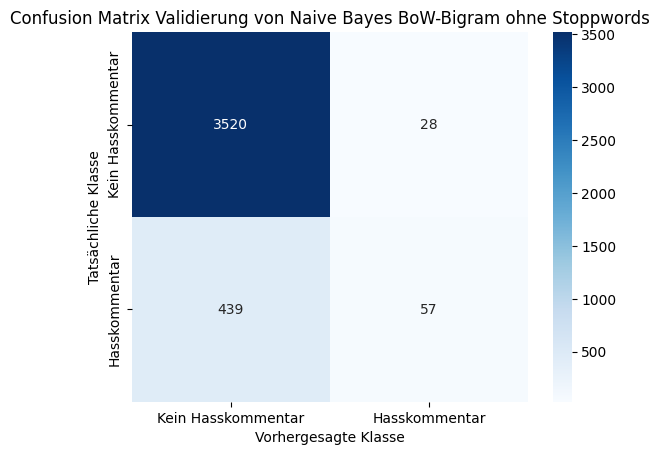

In [37]:
# Confusion Matrix

cm = metrics.confusion_matrix(y_val, y_val_pred)
sns.heatmap(
    cm,
    annot=True, #zeigt werte an, annotation
    fmt="d", # integer gibt ganze zahl an, sonst mit nachkommastellen
    cmap="Blues",# farbpalette, helle farbe = kleiner wert / dunkle farbe = hoher wert
    xticklabels=["Kein Hasskommentar","Hasskommentar"], #beschriftung der x achse
    yticklabels=["Kein Hasskommentar","Hasskommentar"] #beschriftung y achse
)
plt.title("Confusion Matrix Validierung von Naive Bayes BoW-Bigram ohne Stoppwords")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [38]:
# accuracy
vaccuracy = metrics.accuracy_score(y_val, y_val_pred)
# precision
vprecision = metrics.precision_score(y_val, y_val_pred)
# recall
vrecall = metrics.recall_score(y_val, y_val_pred)
# f1-score
vf1=metrics.f1_score(y_val, y_val_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_val, y_val_pred).ravel()
vspecificity = tn/(tn+fp)
# macro recall
vmacro_recall=metrics.recall_score(y_val, y_val_pred, average='macro')
# macro f1-score
vmacro_f1=metrics.f1_score(y_val, y_val_pred, average='macro')

In [39]:
print("Accuracy: ", vaccuracy)
print("Precision: ", vprecision)
print("Recall: ", vrecall)
print("Specificity: ", vspecificity)
print("F1-Score: ", vf1)
print("Macro Recall: ", vmacro_recall)
print("Macro F1-Score: ", vmacro_f1)

Accuracy:  0.8845202769535113
Precision:  0.6705882352941176
Recall:  0.11491935483870967
Specificity:  0.992108229988726
F1-Score:  0.1962134251290878
Macro Recall:  0.5535137924137179
Macro F1-Score:  0.5670024099136848


**Evalutation Test mit Standard Wert**

In [40]:
y_pred=modelBoWStopp.predict(X_test_vex)

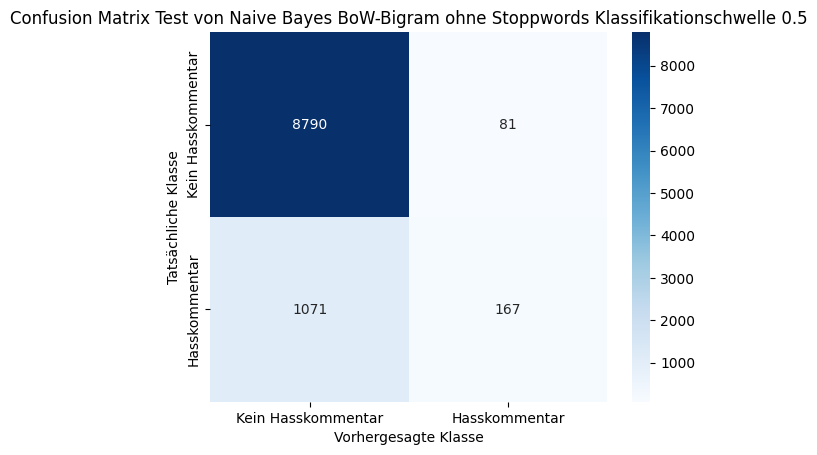

In [41]:
# Confusion Matrix

cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True, #zeigt werte an, annotation
    fmt="d", # integer gibt ganze zahl an, sonst mit nachkommastellen
    cmap="Blues",# farbpalette, helle farbe = kleiner wert / dunkle farbe = hoher wert
    xticklabels=["Kein Hasskommentar","Hasskommentar"], #beschriftung der x achse
    yticklabels=["Kein Hasskommentar","Hasskommentar"] #beschriftung y achse
)
plt.title("Confusion Matrix Test von Naive Bayes BoW-Bigram ohne Stoppwords Klassifikationschwelle 0.5")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [42]:
# accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
# precision
precision = metrics.precision_score(y_test, y_pred)
# recall
recall = metrics.recall_score(y_test, y_pred)
# f1-score
f1=metrics.f1_score(y_test, y_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test, y_pred).ravel()
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test, y_pred, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_pred, average='macro')

In [43]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.8860421406667326
Precision:  0.6733870967741935
Recall:  0.13489499192245558
Specificity:  0.9908691241122759
F1-Score:  0.22476446837146702
Macro Recall:  0.5628820580173657
Macro F1-Score:  0.5816327146469763


In [ ]:
#Modell speichern
import joblib
joblib.dump(modelBoWStopp,"/content/drive/MyDrive/Colab Notebooks/naive_bayes_BoW_ohne_Stopp_model.plk")

['/content/drive/MyDrive/Colab Notebooks/naive_bayes_BoW_ohne_Stopp_model.plk']

**Evaluation mit Optimierten Wert**

In [44]:
y_test_proba=modelBoWStopp.predict_proba(X_test_vex)[:,1] # mit schwellen wert
y_test_pred_opt=(y_test_proba>beste_schwelle).astype(int) # mit optimaler schwellen wert

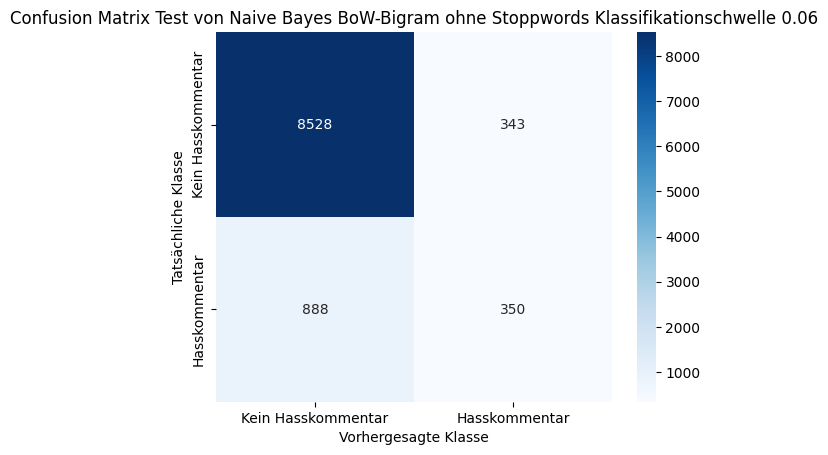

In [45]:
# Confusion Matrix

cm = metrics.confusion_matrix(y_test, y_test_pred_opt)
sns.heatmap(
    cm,
    annot=True, #zeigt werte an, annotation
    fmt="d", # integer gibt ganze zahl an, sonst mit nachkommastellen
    cmap="Blues",# farbpalette, helle farbe = kleiner wert / dunkle farbe = hoher wert
    xticklabels=["Kein Hasskommentar","Hasskommentar"], #beschriftung der x achse
    yticklabels=["Kein Hasskommentar","Hasskommentar"] #beschriftung y achse
)
plt.title("Confusion Matrix Test von Naive Bayes BoW-Bigram ohne Stoppwords Klassifikationschwelle 0.06")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [46]:
# accuracy
accuracy = metrics.accuracy_score(y_test, y_test_pred_opt)
# precision
precision = metrics.precision_score(y_test,  y_test_pred_opt)
# recall
recall = metrics.recall_score(y_test,  y_test_pred_opt)
# f1-score
f1=metrics.f1_score(y_test,  y_test_pred_opt)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test,  y_test_pred_opt).ravel()
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test,  y_test_pred_opt, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_test_pred_opt, average='macro')

In [47]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.8782273221881491
Precision:  0.5050505050505051
Recall:  0.2827140549273021
Specificity:  0.9613346860556871
F1-Score:  0.3625064733298809
Macro Recall:  0.6220243704914946
Macro F1-Score:  0.6475954469782778
